In [1]:
## ====================================
## EET-4501 – Applied Machine Learning
## Project Assignment 6
## ====================================

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("robot_dataset.csv")
display(df.head())
print(df.shape)
df.info()
display(df.describe(include="all"))

,Robot_ID,Task_Type,Component_ID,Sensor_Type,Sensor_Data,Processing_Time (s),Accuracy (%),Environmental_Status,Energy_Consumption (kWh),Human_Intervention_Needed,Obstacle_Detected,Defect_Detected
0,RBT_001,Inspection,CMP_460,LIDAR,1 (obstacle detected),67.0,90.4,Stable,2.2,No,Yes,Yes
1,RBT_002,Assembly,CMP_252,Thermal,85.3 (°C),71.2,98.1,Stable,2.7,Yes,No,No
2,RBT_003,Inspection,CMP_248,Thermal,92% (visual fit),49.2,95.3,Unstable,2.4,No,No,No
3,RBT_004,Welding,CMP_433,Camera,98% (defect-free),74.5,90.2,Stable,2.4,Yes,No,Yes
4,RBT_005,Assembly,CMP_992,Camera,92% (visual fit),64.5,97.2,Unstable,1.8,No,No,No


(500, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Robot_ID                   500 non-null    object 
 1   Task_Type                  500 non-null    object 
 2   Component_ID               500 non-null    object 
 3   Sensor_Type                500 non-null    object 
 4   Sensor_Data                500 non-null    object 
 5   Processing_Time (s)        500 non-null    float64
 6   Accuracy (%)               500 non-null    float64
 7   Environmental_Status       500 non-null    object 
 8   Energy_Consumption (kWh)   500 non-null    float64
 9   Human_Intervention_Needed  500 non-null    object 
 10  Obstacle_Detected          500 non-null    object 
 11  Defect_Detected            500 non-null    object 
dtypes: float64(3), object(9)
memory usage: 47.0+ KB


,Robot_ID,Task_Type,Component_ID,Sensor_Type,Sensor_Data,Processing_Time (s),Accuracy (%),Environmental_Status,Energy_Consumption (kWh),Human_Intervention_Needed,Obstacle_Detected,Defect_Detected
count,500,500,500,500,500,500.000000,500.000000,500,500.000000,500,500,500
unique,500,4,387,4,8,NaN,NaN,2,NaN,2,2,2
top,RBT_001,Assembly,CMP_461,Thermal,1 (obstacle detected),NaN,NaN,Unstable,NaN,Yes,Yes,Yes
freq,1,132,4,136,75,NaN,NaN,251,NaN,253,258,268
mean,NaN,NaN,NaN,NaN,NaN,59.937000,94.920600,NaN,2.014000,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,11.688808,2.900949,NaN,0.582789,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,40.100000,90.000000,NaN,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,49.675000,92.500000,NaN,1.500000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,59.600000,94.900000,NaN,2.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,70.000000,97.500000,NaN,2.500000,NaN,NaN,NaN


In [3]:
df.columns = (
    df.columns.str.strip()
.str.lower()
.str.replace(" ", "_")
)

print(df.columns.tolist())

['robot_id', 'task_type', 'component_id', 'sensor_type', 'sensor_data', 'processing_time_(s)', 'accuracy_(%)', 'environmental_status', 'energy_consumption_(kwh)', 'human_intervention_needed', 'obstacle_detected', 'defect_detected']


In [4]:
binary_columns = ["human_intervention_needed", "obstacle_detected", "defect_detected"]

for col in binary_columns:
    if col in df.columns:
        df[col] = df[col].map({"Yes":1, "No":0})
df[binary_columns].head()

,human_intervention_needed,obstacle_detected,defect_detected
0,0,1,1
1,1,0,0
2,0,0,0
3,1,0,1
4,0,0,0


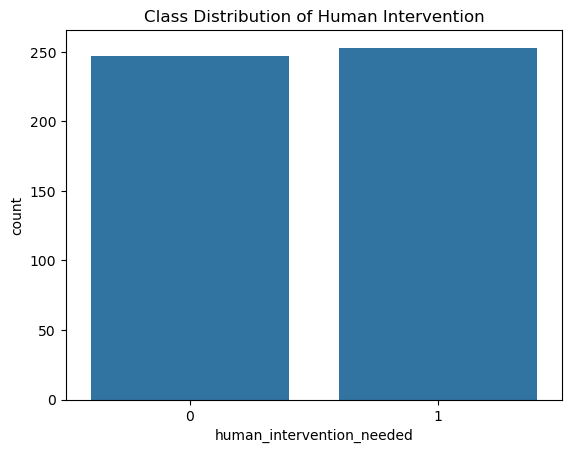

human_intervention_needed
1    253
0    247
Name: count, dtype: int64
human_intervention_needed
1    50.6
0    49.4
Name: proportion, dtype: float64


In [5]:
sns.countplot(x=df['human_intervention_needed'])
plt.title("Class Distribution of Human Intervention")
plt.show()

print(df['human_intervention_needed'].value_counts())
print(df['human_intervention_needed'].value_counts(normalize=True)*100)

In [6]:
print(df.isna().sum())
print((df.isna().mean()*100).sort_values(ascending=False))

robot_id                     0
task_type                    0
component_id                 0
sensor_type                  0
sensor_data                  0
processing_time_(s)          0
accuracy_(%)                 0
environmental_status         0
energy_consumption_(kwh)     0
human_intervention_needed    0
obstacle_detected            0
defect_detected              0
dtype: int64
robot_id                     0.0
task_type                    0.0
component_id                 0.0
sensor_type                  0.0
sensor_data                  0.0
processing_time_(s)          0.0
accuracy_(%)                 0.0
environmental_status         0.0
energy_consumption_(kwh)     0.0
human_intervention_needed    0.0
obstacle_detected            0.0
defect_detected              0.0
dtype: float64


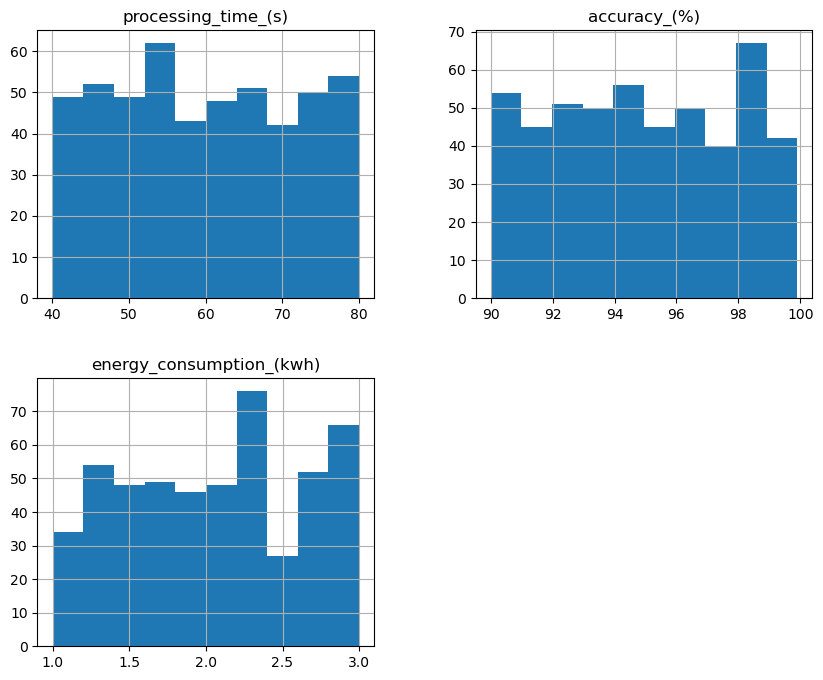

In [7]:
numeric_cols = df.select_dtypes(include=['int64','float64'])

numeric_cols = numeric_cols.drop(columns=["human_intervention_needed", "obstacle_detected", "defect_detected"], errors='ignore')
numeric_cols.hist(figsize=(10,8))
plt.show()

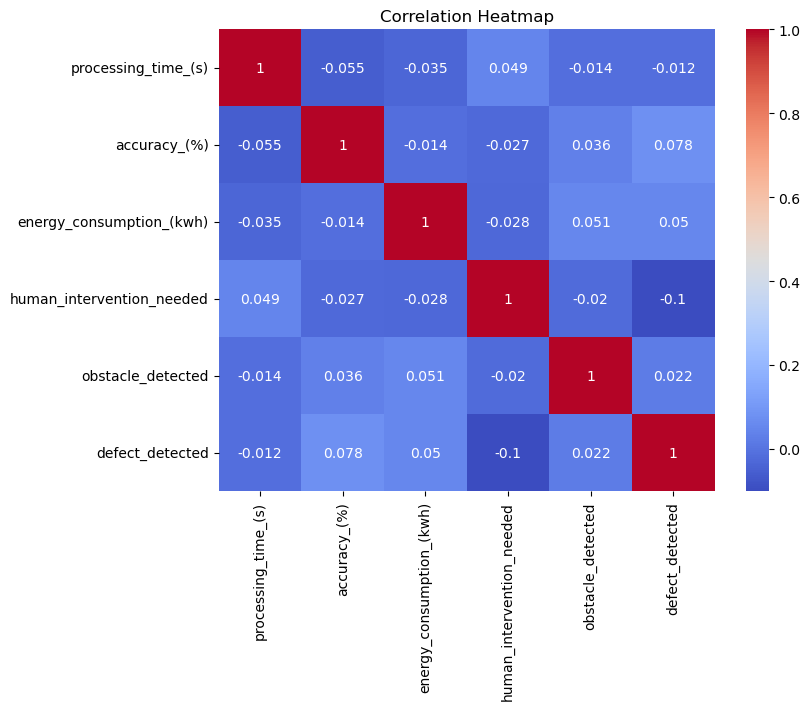

In [8]:
numeric_cols = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

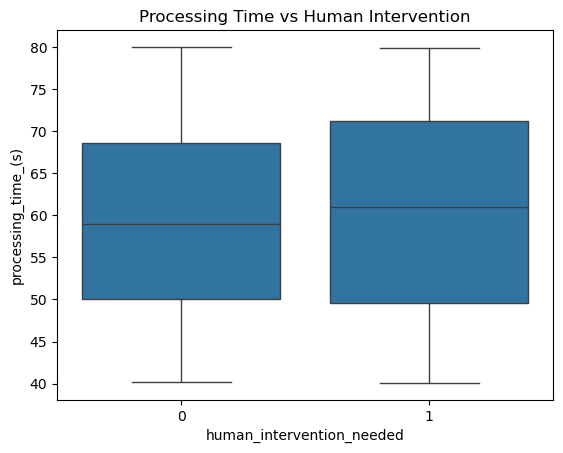

In [9]:
sns.boxplot(x=df['human_intervention_needed'], y=df['processing_time_(s)'])
plt.title("Processing Time vs Human Intervention")
plt.show()

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.select_dtypes(include=['int64','float64']).copy()

X_vif = X_vif.drop(columns=["human_intervention_needed"])

X_vif = X_vif.fillna(X_vif.median())

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])
]

vif_data

,Feature,VIF
0,processing_time_(s),26.265023
1,accuracy_(%),40.242295
2,energy_consumption_(kwh),12.846936
3,obstacle_detected,2.075068
4,defect_detected,2.169562


In [11]:
df[["sensor_value", "sensor_description"]] = df["sensor_data"].str.extract(
r"(-?\d+\.?\d*)\s*\((.*?)\)"
)

df["sensor_value"] = pd.to_numeric(df["sensor_value"], errors="coerce")

df["temperature"] = np.nan
df.loc[df["sensor_description"] == "°C", "temperature"] = df["sensor_value"]

df.drop(columns=[
], inplace=True)
"sensor_value", "sensor_description", "sensor_data"

('sensor_value', 'sensor_description', 'sensor_data')

In [12]:
df["has_temperature"]=df["temperature"].notna().astype(int)

In [13]:
display(df.head())
print(df.isna().sum())

,robot_id,task_type,component_id,sensor_type,sensor_data,processing_time_(s),accuracy_(%),environmental_status,energy_consumption_(kwh),human_intervention_needed,obstacle_detected,defect_detected,sensor_value,sensor_description,temperature,has_temperature
0,RBT_001,Inspection,CMP_460,LIDAR,1 (obstacle detected),67.0,90.4,Stable,2.2,0,1,1,1.0,obstacle detected,NaN,0
1,RBT_002,Assembly,CMP_252,Thermal,85.3 (°C),71.2,98.1,Stable,2.7,1,0,0,85.3,°C,85.3,1
2,RBT_003,Inspection,CMP_248,Thermal,92% (visual fit),49.2,95.3,Unstable,2.4,0,0,0,NaN,NaN,NaN,0
3,RBT_004,Welding,CMP_433,Camera,98% (defect-free),74.5,90.2,Stable,2.4,1,0,1,NaN,NaN,NaN,0
4,RBT_005,Assembly,CMP_992,Camera,92% (visual fit),64.5,97.2,Unstable,1.8,0,0,0,NaN,NaN,NaN,0


robot_id                       0
task_type                      0
component_id                   0
sensor_type                    0
sensor_data                    0
processing_time_(s)            0
accuracy_(%)                   0
environmental_status           0
energy_consumption_(kwh)       0
human_intervention_needed      0
obstacle_detected              0
defect_detected                0
sensor_value                 128
sensor_description           128
temperature                  326
has_temperature                0
dtype: int64


In [14]:
df.drop(columns=["robot_id", "component_id"], inplace=True)

In [15]:
target = "human_intervention_needed"
X = df.drop(target, axis=1)
y = df[target]

In [16]:
print(X.columns)

Index(['task_type', 'sensor_type', 'sensor_data', 'processing_time_(s)',
       'accuracy_(%)', 'environmental_status', 'energy_consumption_(kwh)',
       'obstacle_detected', 'defect_detected', 'sensor_value',
       'sensor_description', 'temperature', 'has_temperature'],
      dtype='object')


In [17]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
numeric_features = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['processing_time_(s)', 'accuracy_(%)', 'energy_consumption_(kwh)', 'obstacle_detected', 'defect_detected', 'sensor_value', 'temperature', 'has_temperature']
Categorical: ['task_type', 'sensor_type', 'sensor_data', 'environmental_status', 'sensor_description']


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [20]:
print("Before preprocessing:")
display(X_train.head())

Before preprocessing:


,task_type,sensor_type,sensor_data,processing_time_(s),accuracy_(%),environmental_status,energy_consumption_(kwh),obstacle_detected,defect_detected,sensor_value,sensor_description,temperature,has_temperature
161,Inspection,Camera,1 (obstacle detected),69.6,94.0,Unstable,2.8,0,1,1.0,obstacle detected,NaN,0
310,Inspection,LIDAR,82.4 (°C),47.0,98.9,Unstable,2.1,0,0,82.4,°C,82.4,1
34,Welding,Thermal,82.4 (°C),66.2,98.3,Unstable,2.2,1,1,82.4,°C,82.4,1
448,Painting,Thermal,85.3 (°C),44.6,95.4,Stable,2.9,1,1,85.3,°C,85.3,1
23,Welding,Camera,0 (no obstacle),55.1,92.0,Stable,2.2,0,1,0.0,no obstacle,NaN,0


In [21]:
X_train_processed = preprocessor.fit_transform(X_train)

In [22]:
cat_feature_names = preprocessor.named_transformers_["categorical"]["onehot"].get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(cat_feature_names)

X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names)
print("After preprocessing:")
display(X_train_processed_df.head())

After preprocessing:


,processing_time_(s),accuracy_(%),energy_consumption_(kwh),obstacle_detected,defect_detected,sensor_value,temperature,has_temperature,task_type_Assembly,task_type_Inspection,...,sensor_data_82.4 (°C),sensor_data_85.3 (°C),sensor_data_92% (visual fit),sensor_data_98% (defect-free),environmental_status_Stable,environmental_status_Unstable,sensor_description_clear path,sensor_description_no obstacle,sensor_description_obstacle detected,sensor_description_°C
0,0.833214,-0.322627,1.319739,-1.020204,0.922958,-0.706833,0.116899,-0.717741,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-1.103446,1.347605,0.129636,-1.020204,-1.083473,1.411077,0.116899,1.393261,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.541858,1.143086,0.299651,0.980196,0.922958,1.411077,0.116899,1.393261,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.309109,0.154582,1.489754,0.980196,0.922958,1.486531,1.398594,1.393261,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,-0.409334,-1.004355,0.299651,-1.020204,0.922958,-0.732851,0.116899,-0.717741,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [23]:
from sklearn.linear_model import LogisticRegression

logreg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
logreg_model.fit(X_train, y_train)
y_pred_lr = logreg_model.predict(X_val)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_val, y_pred_lr))
print("Precision:", precision_score(y_val, y_pred_lr))
print("Recall:", recall_score(y_val, y_pred_lr))
print("F1 Score:", f1_score(y_val, y_pred_lr))

Logistic Regression:
Accuracy: 0.41
Precision: 0.4230769230769231
Recall: 0.43137254901960786
F1 Score: 0.42718446601941745


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, class_weight='balanced'))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)

In [26]:
print("Random Forest:")
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print("Precision:", precision_score(y_val, y_pred_rf))
print("Recall:", recall_score(y_val, y_pred_rf))
print("F1 Score:", f1_score(y_val, y_pred_rf))

Random Forest:
Accuracy: 0.5
Precision: 0.509090909090909
Recall: 0.5490196078431373
F1 Score: 0.5283018867924528


In [27]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_val, y_pred_lr), accuracy_score(y_val, y_pred_rf)],
    "Precision": [precision_score(y_val, y_pred_lr), precision_score(y_val, y_pred_rf)],
    "Recall": [recall_score(y_val, y_pred_lr), recall_score(y_val, y_pred_rf)],
    "F1 Score": [f1_score(y_val, y_pred_lr), f1_score(y_val, y_pred_rf)]
})
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.41,0.423077,0.431373,0.427184
1,Random Forest,0.50,0.509091,0.549020,0.528302


In [28]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_val)

In [29]:
print("\nXGBoost:")
print("Accuracy:", accuracy_score(y_val, y_pred_xgb))
print("Precision:", precision_score(y_val, y_pred_xgb))
print("Recall:", recall_score(y_val, y_pred_xgb))
print("F1 Score:", f1_score(y_val, y_pred_xgb))


XGBoost:
Accuracy: 0.41
Precision: 0.4166666666666667
Recall: 0.39215686274509803
F1 Score: 0.40404040404040403


In [30]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [accuracy_score(y_val, y_pred_lr), accuracy_score(y_val, y_pred_rf), accuracy_score(y_val, y_pred_xgb)],
    "Precision": [precision_score(y_val, y_pred_lr), precision_score(y_val, y_pred_rf), precision_score(y_val, y_pred_xgb)],
    "Recall": [recall_score(y_val, y_pred_lr), recall_score(y_val, y_pred_rf), recall_score(y_val, y_pred_xgb)],
    "F1 Score": [f1_score(y_val, y_pred_lr), f1_score(y_val, y_pred_rf), f1_score(y_val, y_pred_xgb)]
})
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.41,0.423077,0.431373,0.427184
1,Random Forest,0.50,0.509091,0.549020,0.528302
2,XGBoost,0.41,0.416667,0.392157,0.404040


In [31]:
y_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

y_pred_xgb_adj = (y_prob_xgb >=0.4).astype(int)

print("\nXGBoost (Adjusted Threshold):")
print("Accuracy:", accuracy_score(y_val, y_pred_xgb_adj))
print("Precision:", precision_score(y_val, y_pred_xgb_adj))
print("Recall:", recall_score(y_val, y_pred_xgb_adj))
print("F1 Score:", f1_score(y_val, y_pred_xgb_adj))


XGBoost (Adjusted Threshold):
Accuracy: 0.43
Precision: 0.45588235294117646
Recall: 0.6078431372549019
F1 Score: 0.5210084033613446


In [32]:
import numpy as np
thresholds = np.arange(0.2, .8, 0.05)

for t in thresholds:
    y_pred = (y_prob_xgb >= t).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold: {t:.2f}, F1 Score: {f1:.4f}")

Threshold: 0.20, F1 Score: 0.6486
Threshold: 0.25, F1 Score: 0.6531
Threshold: 0.30, F1 Score: 0.6389
Threshold: 0.35, F1 Score: 0.6165
Threshold: 0.40, F1 Score: 0.5210
Threshold: 0.45, F1 Score: 0.4909
Threshold: 0.50, F1 Score: 0.4040
Threshold: 0.55, F1 Score: 0.3736
Threshold: 0.60, F1 Score: 0.2750
Threshold: 0.65, F1 Score: 0.1972
Threshold: 0.70, F1 Score: 0.1538
Threshold: 0.75, F1 Score: 0.1639
Threshold: 0.80, F1 Score: 0.1379


In [33]:
y_prob_rf = rf_model.predict_proba(X_val)[:, 1]
y_pred_rf_025 = (y_prob_rf >=.25).astype(int)

In [34]:
print("Random Forest (Adjusted Threshold):")
print("Accuracy:", accuracy_score(y_val, y_pred_rf_025))
print("Precision:", precision_score(y_val, y_pred_rf_025))
print("Recall:", recall_score(y_val, y_pred_rf_025))
print("F1 Score:", f1_score(y_val, y_pred_rf_025))

Random Forest (Adjusted Threshold):
Accuracy: 0.48
Precision: 0.49473684210526314
Recall: 0.9215686274509803
F1 Score: 0.6438356164383562


In [35]:
rf = rf_model.named_steps["classifier"]

all_feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf.feature_importances_

feature_importances_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
feature_importances_df.head(10)

,Feature,Importance
0,numeric__processing_time_(s),0.174966
1,numeric__accuracy_(%),0.164293
2,numeric__energy_consumption_(kwh),0.140419
4,numeric__defect_detected,0.038861
3,numeric__obstacle_detected,0.036111
5,numeric__sensor_value,0.033866
10,categorical__task_type_Painting,0.029231
11,categorical__task_type_Welding,0.027501
12,categorical__sensor_type_Camera,0.025899
13,categorical__sensor_type_LIDAR,0.025015


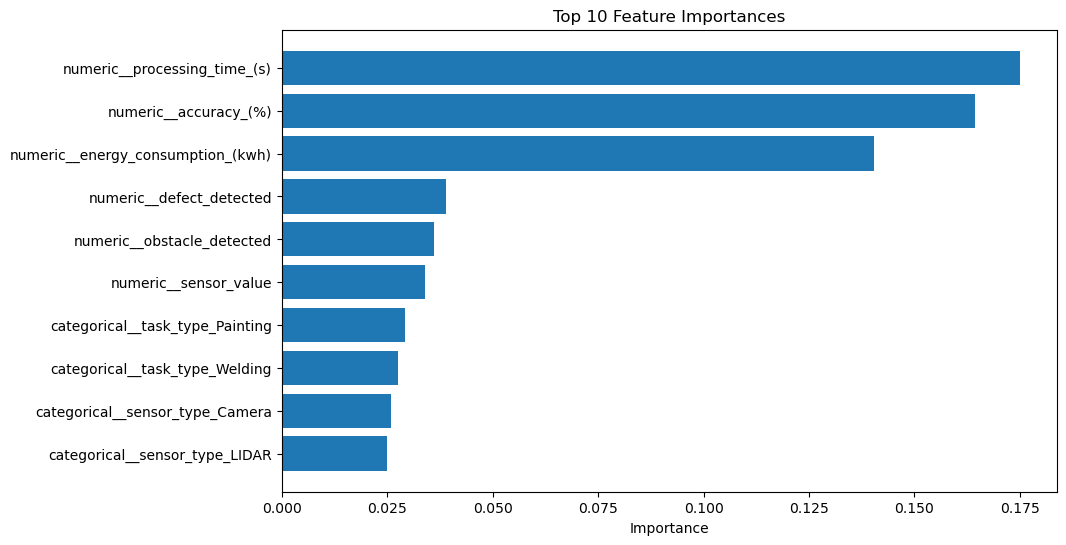

In [36]:
import matplotlib.pyplot as plt
top_features = feature_importances_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.show()

In [37]:
df_exp = df.copy()
df_exp["time_accuracy"] = df_exp["processing_time_(s)"] * df_exp["accuracy_(%)"]

target = "human_intervention_needed"

X_exp = df_exp.drop(target, axis=1)
y_exp = df_exp[target]

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X_train_exp, X_val_exp, y_train_exp, y_val_exp = train_test_split(X_exp, y_exp, test_size=0.2, random_state=42, stratify=y_exp)

numeric_features_exp = X_train_exp.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features_exp = X_train_exp.select_dtypes(include=["object"]).columns.tolist()

preprocessor_exp = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features_exp),
    ("categorical", categorical_pipeline, categorical_features_exp)
])

xgb_model_exp = Pipeline([
    ("preprocessor", preprocessor_exp),
    ("classifier", XGBClassifier(
     n_estimators=100,
     max_depth=3,
     learning_rate=0.1,
     random_state=42,
     eval_metric="logloss"
    ))
])

In [38]:
xgb_model_exp.fit(X_train_exp, y_train_exp)

y_prob_exp = xgb_model_exp.predict_proba(X_val_exp)[:, 1]
y_pred_exp = (y_prob_exp >= 0.25).astype(int)

print("Feature Engineering Model:")
print("Accuracy:", accuracy_score(y_val_exp, y_pred_exp))
print("Precision:", precision_score(y_val_exp, y_pred_exp))
print("Recall:", recall_score(y_val_exp, y_pred_exp))
print("F1 Score:", f1_score(y_val_exp, y_pred_exp))

Feature Engineering Model:
Accuracy: 0.5
Precision: 0.5053763440860215
Recall: 0.9215686274509803
F1 Score: 0.6527777777777778


In [39]:
df_vif = df.copy()
df_vif = df_vif.drop(columns=["accuracy_(%)"])

In [40]:
target = "human_intervention_needed"

X_vif = df_vif.drop(columns=[target])
y_vif = df_vif[target]

X_train_vif, X_val_vif, y_train_vif, y_val_vif = train_test_split(X_vif, y_vif, test_size=0.2, random_state=42, stratify=y_vif)

numeric_features_vif = X_train_vif.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features_vif = X_train_vif.select_dtypes(include=["object"]).columns.tolist()

preprocessor_vif = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features_vif),
    ("categorical", categorical_pipeline, categorical_features_vif)
])

rf_vif_model = Pipeline([
    ("preprocessor", preprocessor_vif),
    ("classifier", RandomForestClassifier(random_state=42, class_weight='balanced'))
])
rf_vif_model.fit(X_train_vif, y_train_vif)
y_prob_rf_vif = rf_vif_model.predict_proba(X_val_vif)[:, 1]
y_pred_rf_vif = (y_prob_rf_vif >= 0.25).astype(int)

print("Random Forest without accuracy:")
print("Accuracy:", accuracy_score(y_val_vif, y_pred_rf_vif))
print("Precision:", precision_score(y_val_vif, y_pred_rf_vif))
print("Recall:", recall_score(y_val_vif, y_pred_rf_vif))
print("F1 Score:", f1_score(y_val_vif, y_pred_rf_vif))

Random Forest without accuracy:
Accuracy: 0.45
Precision: 0.4787234042553192
Recall: 0.8823529411764706
F1 Score: 0.6206896551724138


In [41]:
rf_tuned_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=5, random_state=42, class_weight='balanced'))
])

In [42]:
rf_tuned_model.fit(X_train, y_train)
y_prob_rf_tuned = rf_tuned_model.predict_proba(X_val)[:, 1]
y_pred_rf_tuned = (y_prob_rf_tuned >= 0.25).astype(int)

print("Random Forest (Tuned):")
print("Accuracy:", accuracy_score(y_val, y_pred_rf_tuned))
print("Precision:", precision_score(y_val, y_pred_rf_tuned))
print("Recall:", recall_score(y_val, y_pred_rf_tuned))
print("F1 Score:", f1_score(y_val, y_pred_rf_tuned))

Random Forest (Tuned):
Accuracy: 0.51
Precision: 0.51
Recall: 1.0
F1 Score: 0.6754966887417219


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)]
results = pd.DataFrame([
    ["Logistic Regression", .50, *get_metrics(y_val, y_pred_lr)],
    ["Random Forest", .50, *get_metrics(y_val, y_pred_rf)],
    ["XGBoost", .50, *get_metrics(y_val, y_pred_xgb)],
    ["Random Forest (Adjusted Threshold .25)", .25, *get_metrics(y_val, y_pred_rf_025)],
    ["Random Forest (No Accuracy Feature - VIF)", .25, *get_metrics(y_val_vif, y_pred_rf_vif)],
    ["Random Forest (Tuned - BEST)", .25, *get_metrics(y_val, y_pred_rf_tuned)]
],
                       
    columns=["Model", "Threshold", "Accuracy", "Precision", "Recall", "F1 Score"]
)
results.round(2)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.50,0.41,0.42,0.43,0.43
1,Random Forest,0.50,0.50,0.51,0.55,0.53
2,XGBoost,0.50,0.41,0.42,0.39,0.40
3,Random Forest (Adjusted Threshold .25),0.25,0.48,0.49,0.92,0.64
4,Random Forest (No Accuracy Feature - VIF),0.25,0.45,0.48,0.88,0.62
5,Random Forest (Tuned - BEST),0.25,0.51,0.51,1.00,0.68
